<a href="https://colab.research.google.com/github/highlows-ai/industry-topology-map/blob/industry-topology-v2/industry_topology_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_11044/2067425662.py:63: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


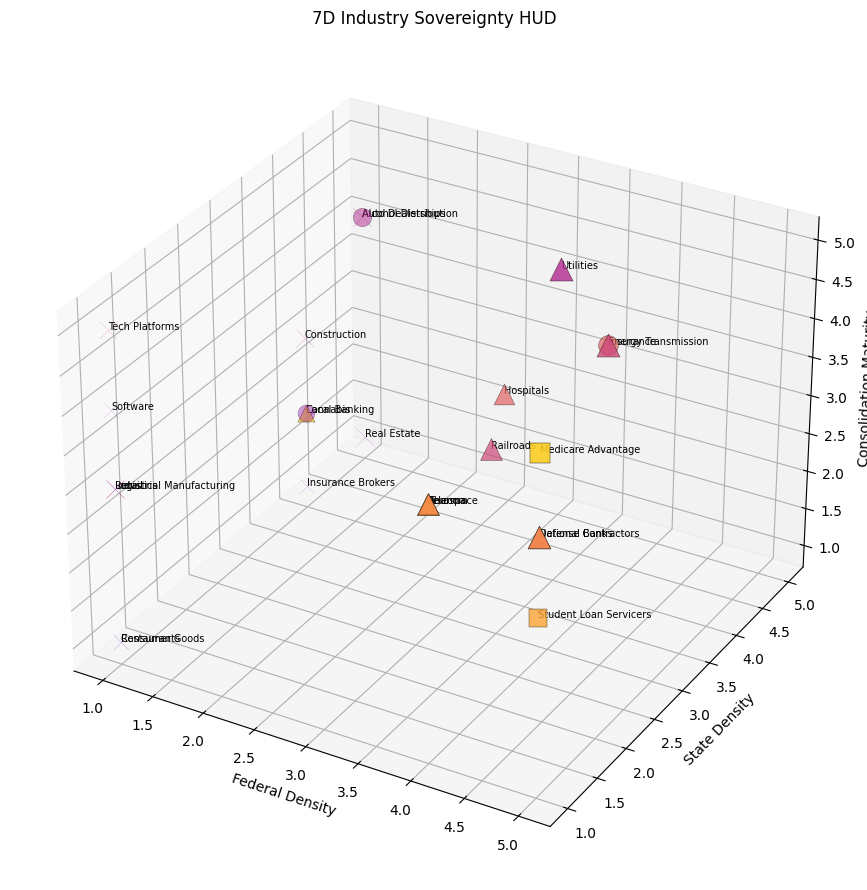

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# === 1. Core 3D coordinates (same as your baseline) ===
industries = [
    "Medicare Advantage", "Defense Contractors", "Student Loan Servicers",
    "Aerospace", "Railroads", "National Banks", "Pharma", "Telecom",
    "Insurance", "Utilities", "Hospitals", "Energy Transmission", "Cannabis",
    "Real Estate", "Alcohol Distribution", "Local Banking", "Construction",
    "Insurance Brokers", "Auto Dealerships", "Tech Platforms", "Consumer Goods",
    "Logistics", "Restaurants", "Software", "Retail", "Industrial Manufacturing"
]

federal = np.array([5,5,5,4,4,5,4,4,4,3,3,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
state = np.array([1,1,1,1,2,1,1,1,4,5,4,4,4,5,5,4,4,4,5,1,1,1,1,1,1,1])
consol = np.array([5,4,3,4,4,4,4,4,4,4,3,4,2,1,4,2,3,1,4,5,1,3,1,4,3,3])

# === 2. Extra dimensions ===
# Regulatory volatility (0–1) → color
reg_vol = np.array([
    0.9,0.7,0.8,0.6,0.5,0.7,0.8,0.7,0.6,0.4,0.6,0.5,
    0.9,0.3,0.4,0.3,0.4,0.2,0.4,0.5,0.2,0.4,0.2,0.3,0.3,0.4
])

# Capital intensity (0–1) → point size
cap_int = np.array([
    0.7,0.9,0.5,0.8,0.8,0.8,0.8,0.7,0.6,0.9,0.7,0.9,
    0.4,0.6,0.5,0.4,0.5,0.2,0.5,0.4,0.3,0.4,0.2,0.3,0.4,0.6
])

# Government revenue dependence (0–1) → marker shape
gov_dep = np.array([
    0.9,0.8,0.9,0.6,0.5,0.8,0.7,0.6,0.4,0.5,0.5,0.6,
    0.7,0.1,0.2,0.2,0.1,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0
])

# Sovereignty risk (0–1) → opacity
sov_risk = np.array([
    0.9,0.8,0.8,0.7,0.7,0.8,0.8,0.7,0.7,0.8,0.7,0.8,
    0.7,0.3,0.5,0.4,0.4,0.3,0.5,0.4,0.2,0.3,0.2,0.3,0.3,0.4
])

# === 3. Visual encodings ===
cmap = plt.cm.plasma
colors = cmap(reg_vol) # color ← regulatory volatility
sizes = 50 + cap_int * 250 # size ← capital intensity

def marker_for(dep):
    if dep > 0.8: return 's' # square: heavy gov dependence
    if dep > 0.4: return '^' # triangle: moderate
    if dep > 0.1: return 'o' # circle: light
    return 'x' # cross: none

# === 4. Plot ===
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')

for x, y, z, col, sz, dep, alpha, label in zip(
    federal, state, consol, colors, sizes, gov_dep, sov_risk, industries
):
    m = marker_for(dep)
    ax.scatter(
        x, y, z,
        c=[col],
        s=sz,
        marker=m,
        alpha=alpha,
        edgecolor='k',
        linewidth=0.3
    )
    ax.text(x, y, z, label, fontsize=7)

ax.set_xlabel("Federal Density")
ax.set_ylabel("State Density")
ax.set_zlabel("Consolidation Maturity")
ax.set_title("7D Industry Sovereignty HUD")

plt.tight_layout()
plt.show()